# ML Pipeline Quickstart

This notebook exercises the new ML pipeline utilities: S3 helpers, audio decoding, mel feature generation, and PCA.

In [7]:
from pathlib import Path
import sys
import pandas as pd

# Add repo/python to path so `ml` is importable
repo_root = Path.cwd().parents[2]
sys.path.insert(0, str(repo_root / 'python'))

from ml.storage import read_parquet_uri, read_audio_path_ffmpeg
from ml.features.audio_mel import MelSegmentsConfig, generate_mel_segments
from ml.analysis.pca import pca_from_mel_df, pca_from_tabular_df


## 1) Decode a WebM with ffmpeg (local)

In [8]:
sample_webm = Path('/run/media/cbaguilar/T7/wyze_dump/camera=Santa_Teresa_Cam_1/date=2026-02-25/Santa_Teresa_Cam_1_2026-02-25T07-23-07-263Z_chunk=000001.webm')
y, sr, subtype = read_audio_path_ffmpeg(sample_webm, sample_rate=16000, mono=True)
(y.shape, sr, subtype)

((159360,), 16000, 'ffmpeg')

## 2) Generate mel features for a small subset
This will write shards + a manifest under the output directory.

In [9]:
cfg = MelSegmentsConfig(
    segments_root=Path('/run/media/cbaguilar/T7/wyze_dump'),
    segments_manifest='',
    out_dir=Path('/tmp/wyze_mel_test'),
    site='wyze',
    limit_segments=100,
    sample_rate=16000,
    target_seconds=10.0,
    decoder='ffmpeg',
)
manifest_path = generate_mel_segments(cfg)
manifest_path

[write] /tmp/wyze_mel_test/dataset=audio_mel_segments/site=wyze/date=unknown/mel_shard_00000.npz segments=100 shape=(100, 64, 622)
[OK] mel manifest rows=100 -> /tmp/wyze_mel_test/dataset=audio_mel_segments/site=wyze/audio_mel_segments.parquet


PosixPath('/tmp/wyze_mel_test/dataset=audio_mel_segments/site=wyze/audio_mel_segments.parquet')

## 3) Load manifest and run PCA on mel shards

In [10]:
import re

mel_df = pd.read_parquet(manifest_path).copy()

# Derive camera from path so PCA is computed per camera (not mixed)
def _camera_from_row(row):
    for col in ['segment_path', 'source_path']:
        v = row.get(col)
        if isinstance(v, str) and v:
            m = re.search(r'camera=([^/]+)', v)
            if m:
                return m.group(1)
            m = re.search(r'/derived/([^/]+)/', v)
            if m:
                return m.group(1)
    return 'unknown'

mel_df['camera'] = mel_df.apply(_camera_from_row, axis=1)
sorted(mel_df['camera'].unique())

camera_name = sorted(mel_df['camera'].unique())[0]  # change this as needed
cam_df = mel_df[mel_df['camera'] == camera_name].copy()
pca_out_dir = Path('/tmp/wyze_pca_test') / f'camera={camera_name}'
res = pca_from_mel_df(cam_df, pca_out_dir, limit=min(1000, len(cam_df)), sample_mode='random')
print('camera:', camera_name, 'rows:', len(cam_df))
res


camera: pryor_farms_1 rows: 100


PCAResult(points_path=PosixPath('/tmp/wyze_pca_test/camera=pryor_farms_1/pca_points.parquet'), model_path=PosixPath('/tmp/wyze_pca_test/camera=pryor_farms_1/pca_model.npz'), meta_path=PosixPath('/tmp/wyze_pca_test/camera=pryor_farms_1/pca_meta.json'))

### Plotly scatter with click-to-open

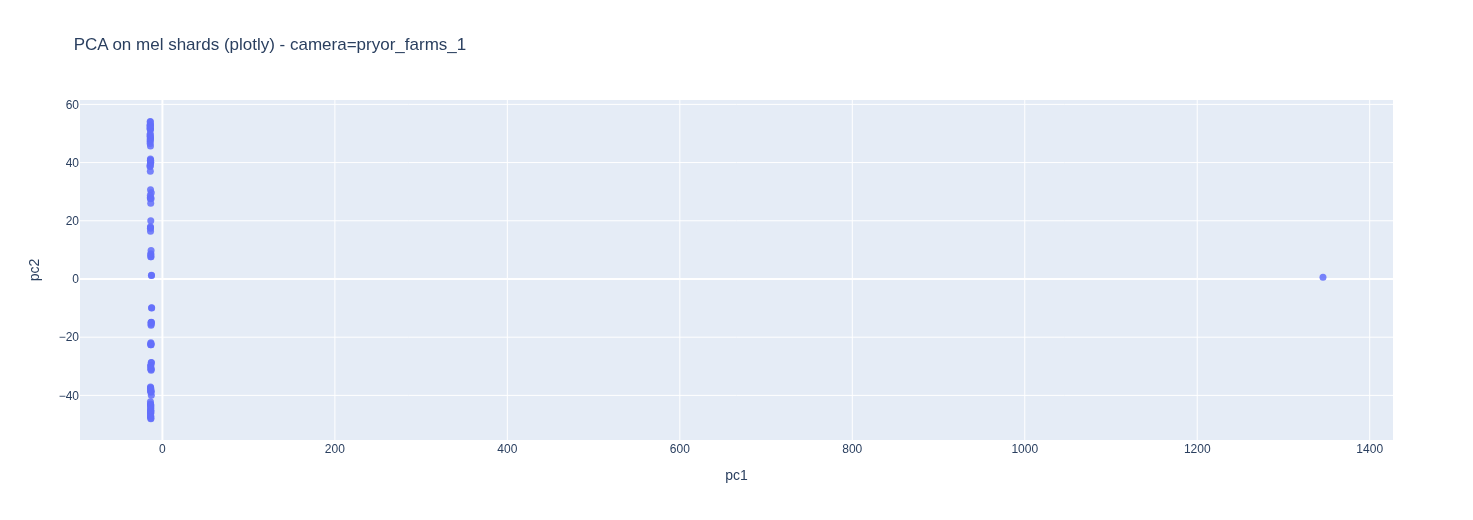

Hover a point to inspect the file/path. PCA is now per-camera.


In [11]:
import plotly.express as px

pca_points = pd.read_parquet(res.points_path)
label_col = None
for c in ['segment_path', 'segment_relpath', 'source_name', 'mel_shard_path']:
    if c in pca_points.columns:
        label_col = c
        break

if label_col is None:
    pca_points = pca_points.copy()
    pca_points['point_label'] = pca_points.index.astype(str)
    label_col = 'point_label'

fig = px.scatter(
    pca_points,
    x='pc1',
    y='pc2',
    hover_data=[label_col],
    title=f'PCA on mel shards (plotly) - camera={camera_name}'
)
fig.update_traces(marker=dict(size=7, opacity=0.85))
fig.update_layout(height=520)
fig.show()
print('Hover a point to inspect the file/path. PCA is now per-camera.')


## 4) PCA on tabular data (example)

In [6]:
tab_df = pd.DataFrame({
    'a': [1,2,3,4,5],
    'b': [2,1,2,1,2],
    'c': [5,4,3,2,1],
})
tab_res = pca_from_tabular_df(tab_df, Path('/tmp/tab_pca'))
tab_res

PCAResult(points_path=PosixPath('/tmp/tab_pca/pca_points.parquet'), model_path=PosixPath('/tmp/tab_pca/pca_model.npz'), meta_path=PosixPath('/tmp/tab_pca/pca_meta.json'))